# Main Report

In [ ]:
# # Reload all modules before executing the notebook
# %load_ext autoreload
# %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
%cd drive/MyDrive/project/aircraft_classification
%ls -la

/content/drive/MyDrive/project/aircraft_classification
total 43893
drwx------ 2 root root     4096 Aug 20 20:26 dinov3/
drwx------ 4 root root     4096 Aug 20 01:15 FGVCAircraft_Subset20/
drwx------ 2 root root     4096 Aug 20 20:38 __pycache__/
-rw------- 1 root root 44828427 Aug 20 21:02 resnet_unfrozen_h1_best.pth
-rw------- 1 root root    93022 Aug 20 21:03 training_results_model_h1.png
-rw------- 1 root root     5579 Aug 20 14:01 utils.py
drwx------ 2 root root     4096 Aug 20 20:26 weights/
-rw------- 1 root root     1636 Aug 20 21:03 weights_model_h1.pkl


In [3]:
from utils import set_seed, train_epoch, setup_model

In [4]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Torch for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision for datasets and transformations
import torchvision
import torchvision.transforms as transforms
import tqdm

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

set_seed(42)

Using device: cuda


In [5]:
# Imagenet preprocessing
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Validation / Test transform
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load test dataset
test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/test', transform=val_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)
class_names = test_dataset.classes
print(f"Number of test samples: {len(test_dataset)}")

Number of test samples: 669


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### Compare learning curves across 4 models and select the best model

* **Baseline:** ResNet-18 (Frozen) + SGD
* **H1 (Experiment 1):** ResNet-18 (Unfrozen) + AdamW + CosineAnnealingLR
* **H2 (Experiment 2):** ResNet-50 (Unfrozen) + AdamW + CosineAnnealingLR [WON when epoch = 32]
* **H3 (Experiment 3):** DINOv3 (Linear Probing) + AdamW + CosineAnnealingLR [WON when epoch = 10]

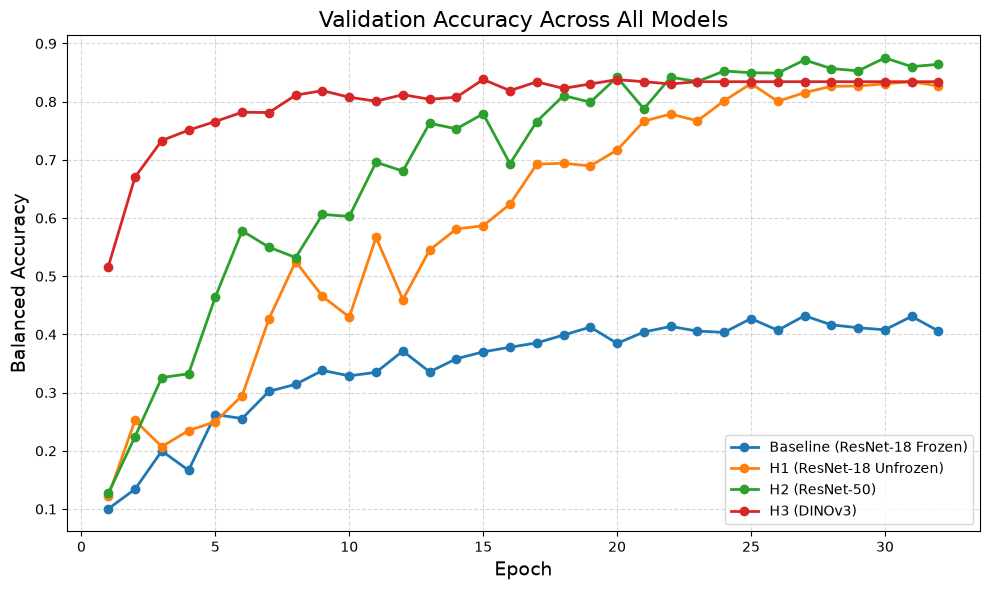


--- Final Model Comparison ---


,Experiment,Final Val Accuracy
0,Baseline (ResNet-18 Frozen),40.58%
1,H1 (ResNet-18 Unfrozen),82.69%
2,H2 (ResNet-50),86.43%
3,H3 (DINOv3),83.43%


In [5]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the sweep results
try:
    with open('sweep_results.pkl', 'rb') as f:
        results = pickle.load(f)
except FileNotFoundError:
    print("sweep_results.pkl not found! Please run development_full.ipynb first.")
    results = {}

if results:
    # 1. Plot Individual Curves
    for name, res in results.items():
        history = res["history"]
        epochs = range(1, len(history["train_loss"]) + 1)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Training Results: {name.upper()}", fontsize=16)
        
        ax1.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
        ax1.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.set_title("Epoch vs Loss")
        ax1.legend()
        ax1.grid(True)
        
        ax2.plot(epochs, history["train_acc"], label="Train Acc", marker="o")
        ax2.plot(epochs, history["val_acc"], label="Val Acc", marker="o")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("Accuracy")
        ax2.set_title("Epoch vs Accuracy")
        ax2.legend()
        ax2.grid(True)
        
        plt.show()

    # 2. Comparative Analysis Table
    summary_data = []
    for name, res in results.items():
        summary_data.append({"Model": name.upper(), "Best Validation Accuracy": res["best_val_acc"]})

    df_summary = pd.DataFrame(summary_data).sort_values(by="Best Validation Accuracy", ascending=False)
    display(df_summary)

    # 3. Validation Accuracy across Epochs for all models
    plt.figure(figsize=(12, 7))
    for name, res in results.items():
        history = res["history"]
        epochs = range(1, len(history["val_acc"]) + 1)
        plt.plot(epochs, history["val_acc"], label=f"{name.upper()} Val Acc", marker="o", linewidth=2)

    plt.title("Validation Accuracy Across All Models Over Time")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


### Retrain the best model on the whole TrainVal dataset

In [7]:
# Data augmentation for training dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load the FULL trainval dataset (100% data, no splitting)
full_trainval_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/trainval', transform=train_transform)
full_train_loader = torch.utils.data.DataLoader(full_trainval_dataset, batch_size=16, shuffle=True, num_workers=4)



Number of total training samples: 1331


In [6]:
def get_model(model_name, num_classes, freeze_backbone=False):
    if model_name == 'resnet18':
        import torchvision.models as models
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'resnet50':
        import torchvision.models as models
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'efficientnet_b0':
        import torchvision.models as models
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'dinov3':
        class DinoV3Classifier(nn.Module):
            def __init__(self, repo_dir, weights, num_classes, freeze_backbone=False):
                super().__init__()
                self.backbone = torch.hub.load(
                    repo_dir,
                    'dinov3_vits16',
                    source='local',
                    weights=weights
                )
                embed_dim = getattr(self.backbone, 'embed_dim', 384)
                self.fc = nn.Linear(embed_dim, num_classes)
                
                if freeze_backbone:
                    for param in self.backbone.parameters():
                        param.requires_grad = False

            def forward(self, x):
                features = self.backbone(x)
                return self.fc(features)
        
        REPO_DIR = './dinov3'
        WEIGHTS_PATH = './weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth'
        model = DinoV3Classifier(
            repo_dir=REPO_DIR,
            weights=WEIGHTS_PATH,
            num_classes=num_classes,
            freeze_backbone=freeze_backbone
        )
    else:
        raise ValueError(f"Model {model_name} not supported")
    return model


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Initialized Unfrozen ResNet-50


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
# Pick the best model based on the sweep in development_full
best_model_name = 'dinov3'  # You can change this to 'resnet50' or 'efficientnet_b0'
print(f"Loading best model choice: {best_model_name}")

final_model = get_model(best_model_name, num_classes=20, freeze_backbone=False).to(device)


In [8]:
# Retrain on full trainval dataset
lr = 0.001
total_epochs = 32

# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimizer (filter out frozen parameters)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, final_model.parameters()), lr=lr, weight_decay=1e-4
)

# Initialize Cosine Annealing Learning Rate Scheduler
import tqdm
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

patience = 5
epochs_no_improve = 0
best_train_loss = float("inf")

epoch_pbar = tqdm.tqdm(range(total_epochs), colour='blue')
for epoch in epoch_pbar:
    mean_train_loss, train_accuracy = train_epoch(
        final_model, full_train_loader, criterion, optimizer, epoch, device
    )
    scheduler.step()
    epoch_pbar.write(f"Epoch [{epoch+1:3d}/{total_epochs}] | train_loss: {mean_train_loss:.4f} | train_acc: {train_accuracy:.4f}")
    
    if mean_train_loss < best_train_loss:
        best_train_loss = mean_train_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

print("Retraining Complete!")


  0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  3%|▎         | 1/32 [00:21<11:19, 21.91s/it]

Epoch [  1/32] | train_loss: 2.7907 | train_acc: 0.1307


  6%|▋         | 2/32 [00:40<10:04, 20.14s/it]

Epoch [  2/32] | train_loss: 2.4841 | train_acc: 0.2141


  9%|▉         | 3/32 [00:58<09:16, 19.18s/it]

...

Epoch [ 30/32] | train_loss: 0.4350 | train_acc: 0.8595


 97%|█████████▋| 31/32 [09:41<00:18, 18.54s/it]

Epoch [ 31/32] | train_loss: 0.4283 | train_acc: 0.8670


100%|██████████| 32/32 [10:00<00:00, 18.75s/it]

Epoch [ 32/32] | train_loss: 0.4574 | train_acc: 0.8497
Retraining Complete!


### Evaluate the best model on Test Set

In [9]:
def evaluate_on_test(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    all_probs = []
    with torch.no_grad():
        for i, data in tqdm.tqdm(enumerate(dataloader, 0), total=len(dataloader), desc="Evaluating on Test Set"):
            inputs, labels = data
            inputs = inputs.to(device)
            
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            predicted = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate average per-class accuracy (balanced accuracy)
    test_accuracy = balanced_accuracy_score(all_labels, all_preds)
    print(f"\nAverge per-class accuracy on Test Set using the best model: {test_accuracy:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_labels, all_preds, all_probs, test_accuracy

all_labels, all_preds, all_probs, test_accuracy = evaluate_on_test(final_model, test_loader, device)

Evaluating on Test Set: 100%|██████████| 42/42 [01:57<00:00,  2.79s/it]


Averge per-class accuracy on Test Set using the best model: 0.8622

Classification Report:
              precision    recall  f1-score   support

    class_00       0.60      0.62      0.61        34
    class_01       0.59      0.52      0.55        33
    class_02       0.88      0.91      0.90        33
    class_03       0.78      0.91      0.84        34
    class_04       0.86      0.91      0.89        34
    class_05       0.88      0.70      0.78        33
    class_06       1.00      0.97      0.99        34
    class_07       0.91      0.91      0.91        33
    class_08       0.86      0.88      0.87        34
    class_09       0.88      0.85      0.86        33
    class_10       0.94      0.94      0.94        34
    class_11       0.92      1.00      0.96        33
    class_12       0.94      0.88      0.91        33
    class_13       0.91      0.94      0.93        33
    class_14       0.88      0.88      0.88        34
    class_15       0.89      0.94      0.91

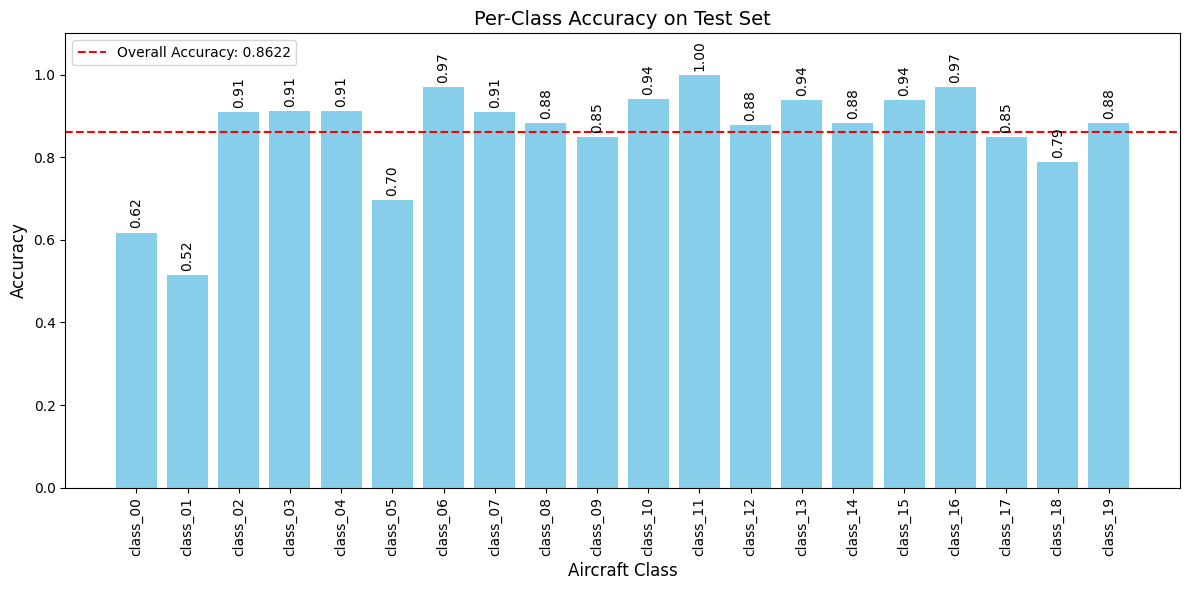

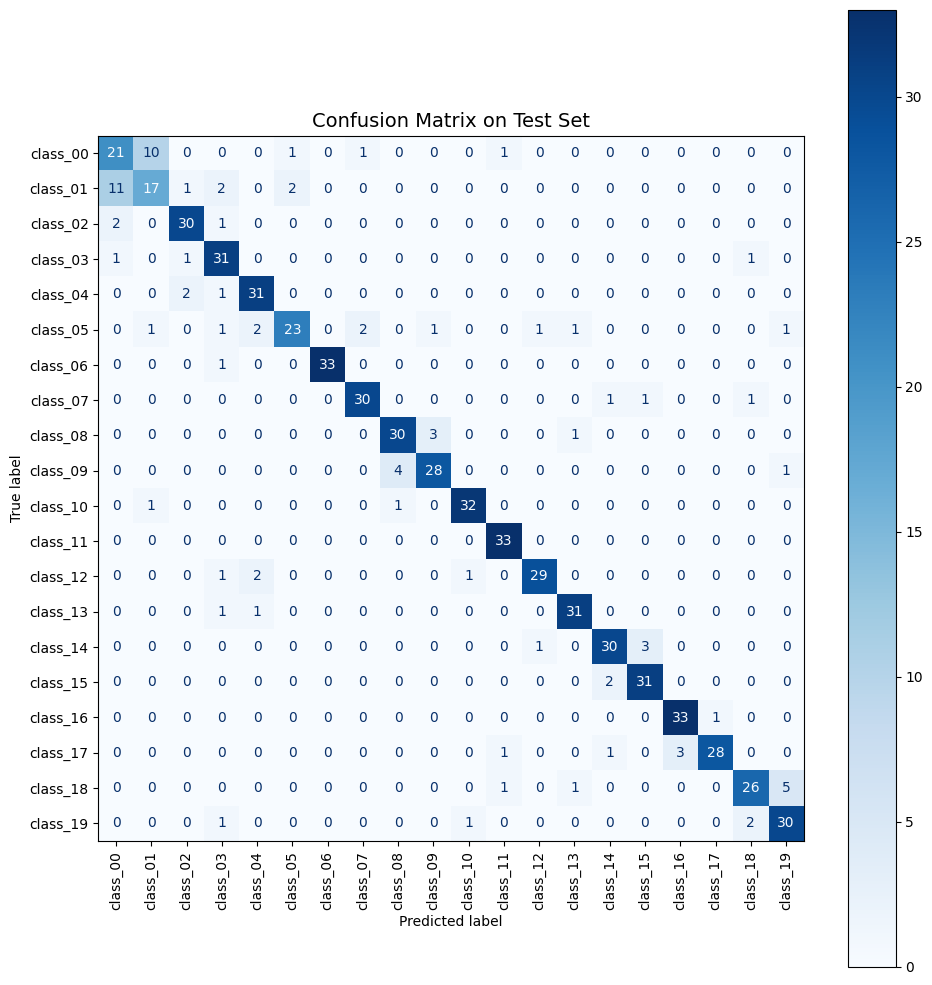

In [10]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Compute per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# 1. Plot Per-Class Accuracy Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(class_names, per_class_acc, color='skyblue')
plt.xlabel('Aircraft Class', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy on Test Set', fontsize=14)
plt.xticks(rotation=90)
plt.ylim(0, 1.1)
plt.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Overall Accuracy: {test_accuracy:.4f}')

# Add text labels above the bars
for i, acc in enumerate(per_class_acc):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom', rotation=90, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
ax.grid(False)
plt.title('Confusion Matrix on Test Set', fontsize=14)
plt.tight_layout()
plt.show()
